# Stage 6 — Semi-Supervised Extension

**Motivation:** Only 3,606 of 12,356 unique tokens carry labels. The remaining **~8,750 unlabeled tokens** have no symbol collision (so we can't call them spam) and are not in the verified list (so we can't call them legit). Semi-supervised learning lets us exploit their feature patterns to potentially improve the classifier.

**Two approaches:**
- **Approach A — Confidence Thresholding (Pseudo-Labeling):** Use the best supervised model to predict unlabeled tokens. Add high-confidence predictions as pseudo-labels, retrain, compare on the original test set.
- **Approach B — Self-Training (sklearn):** Iteratively expand the labeled set by adding confident predictions, using `SelfTrainingClassifier`.

**Evaluation:** Both approaches are benchmarked against the supervised-only baseline on the **held-out test set** (never used in training).

## 1. Imports & Setup

In [1]:
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import entropy as scipy_entropy

from sklearn.semi_supervised import SelfTrainingClassifier
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score
)
import lightgbm as lgb

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
print('Libraries loaded.')

Libraries loaded.


## 2. Load Supervised Artifacts & Test Set

In [2]:
# Best supervised model (LightGBM tuned) and feature list
best_model   = joblib.load('models/best_model.joblib')
FEATURE_COLS = joblib.load('data/processed/feature_cols.joblib')

# Training set (unscaled — LightGBM is scale-invariant)
train_u = pd.read_parquet('data/processed/train_unscaled.parquet')
X_train = train_u[FEATURE_COLS].values
y_train = train_u['label'].astype(int).values

# Test set — held out throughout
test_u  = pd.read_parquet('data/processed/test_unscaled.parquet')
X_test  = test_u[FEATURE_COLS].values
y_test  = test_u['label'].astype(int).values

print(f'Train: {len(y_train):,}  (spam={( y_train==0).sum()}, legit={(y_train==1).sum()})')
print(f'Test:  {len(y_test):,}   (spam={( y_test==0).sum()},  legit={(y_test==1).sum()})')
print(f'Features: {len(FEATURE_COLS)}')

Train: 2,524  (spam=1405, legit=1119)
Test:  541   (spam=301,  legit=240)
Features: 16


## 3. Rebuild Unlabeled Token Features

Re-run the same feature engineering pipeline from `preprocessing.ipynb` on all tokens, then extract the unlabeled subset (those with `label = NaN`).

In [3]:
# --- Load raw data ---
df_transfers = pd.read_parquet('data/transfers_20000000.parquet', engine='pyarrow')
df_account   = pd.read_csv('data/account_labels.csv')
df_token     = pd.read_csv('data/token_labels.csv')
print(f'Transfers loaded: {df_transfers.shape}')

Transfers loaded: (3654710, 15)


In [4]:
# --- Transfer-level flags (identical to preprocessing.ipynb) ---
verified_addresses = set(
    df_token[df_token['Address'].str.startswith('0x', na=False)]['Address'].str.lower()
)
verified_symbol_map = (
    df_token[df_token['Address'].str.startswith('0x', na=False)]
    .set_index('Symbol')['Address'].str.lower().to_dict()
)

df_tok = df_transfers[
    df_transfers['category'].isin(['erc20','token','erc721','erc1155','specialnft'])
].copy()

df_tok['contract_addr'] = df_tok['rawContract.address'].str.lower()
df_tok['asset_upper']   = df_tok['asset'].str.upper()
df_tok['block_int']     = df_tok['blockNum'].apply(
    lambda x: int(x, 16) if isinstance(x, str) else x
)
df_tok['is_verified']   = df_tok['contract_addr'].isin(verified_addresses).astype(int)

def check_collision(row):
    sym, addr = row['asset_upper'], row['contract_addr']
    if not isinstance(sym, str) or not isinstance(addr, str): return 0
    canonical = verified_symbol_map.get(sym)
    return 1 if (canonical and canonical != addr) else 0

df_tok['symbol_collision'] = df_tok.apply(check_collision, axis=1)
df_tok['value_is_zero']    = (df_tok['value'].fillna(0) == 0).astype(int)
print(f'Token transfers: {len(df_tok):,}  |  Unique contracts: {df_tok["contract_addr"].nunique():,}')

Token transfers: 2,161,313  |  Unique contracts: 12,356


In [5]:
# --- Aggregate features (identical to preprocessing.ipynb) ---
def cat_entropy(x):
    counts = x.value_counts(normalize=True)
    return scipy_entropy(counts)

token_features = df_tok.groupby('contract_addr').agg(
    n_transfers         = ('hash',            'count'),
    n_unique_senders    = ('from',            'nunique'),
    n_unique_receivers  = ('to',              'nunique'),
    value_mean          = ('value',           'mean'),
    value_std           = ('value',           'std'),
    value_null_ratio    = ('value',           lambda x: x.isnull().mean()),
    n_distinct_blocks   = ('block_int',       'nunique'),
    block_range         = ('block_int',       lambda x: x.max() - x.min()),
    unique_values_count = ('value',           'nunique'),
    zero_value_ratio    = ('value_is_zero',   'mean'),
    symbol_collision    = ('symbol_collision','max'),
    is_verified         = ('is_verified',     'max'),
    category_entropy    = ('category',        cat_entropy),
).reset_index()

token_features['sender_receiver_ratio'] = (
    token_features['n_unique_senders'] / token_features['n_unique_receivers'].replace(0,1)
)
token_features['transfers_per_block'] = (
    token_features['n_transfers'] / token_features['n_distinct_blocks'].replace(0,1)
)

# Additional features
sender_counts       = df_tok.groupby(['contract_addr','from'])['hash'].count()
top1_sender_share   = (sender_counts.groupby(level=0).max() /
                       df_tok.groupby('contract_addr')['hash'].count()).rename('top1_sender_share')
token_features['top1_sender_share'] = token_features['contract_addr'].map(top1_sender_share)

def gini_coefficient(counts):
    arr = np.sort(np.array(counts, dtype=float))
    n   = len(arr)
    if n <= 1 or arr.sum() == 0: return 0.0
    idx = np.arange(1, n + 1)
    return (2 * (idx * arr).sum()) / (n * arr.sum()) - (n + 1) / n

receiver_counts = df_tok.groupby(['contract_addr','to'])['hash'].count()
gini_map        = receiver_counts.groupby(level=0).apply(gini_coefficient)
token_features['receiver_concentration'] = token_features['contract_addr'].map(gini_map)

labeled_addresses = set(df_account['address'].str.lower())
sender_label_map  = df_tok.groupby('contract_addr')['from'].apply(
    lambda addrs: int(any(str(a).lower() in labeled_addresses for a in addrs))
)
token_features['sender_is_labeled'] = (
    token_features['contract_addr'].map(sender_label_map).fillna(0).astype(int)
)

# Label construction
token_features['label'] = token_features.apply(
    lambda r: 1 if r['is_verified']==1 else (0 if r['symbol_collision']==1 else float('nan')),
    axis=1
)

print(f'Total tokens:    {len(token_features):,}')
print(f'Labeled:         {token_features["label"].notna().sum():,}')
print(f'Unlabeled:       {token_features["label"].isna().sum():,}')

Total tokens:    12,356
Labeled:         3,606
Unlabeled:       8,750


In [6]:
# --- Apply same log1p transforms and extract unlabeled ---
LOG_FEATURES = [
    'n_transfers','n_unique_senders','n_unique_receivers',
    'value_mean','value_std','sender_receiver_ratio',
    'transfers_per_block','n_distinct_blocks','block_range','unique_values_count',
]

unlabeled = token_features[token_features['label'].isna()].copy()
X_unlabeled = unlabeled[FEATURE_COLS].copy()

# Impute any nulls with training set medians
train_medians = train_u[FEATURE_COLS].median()
X_unlabeled   = X_unlabeled.fillna(train_medians)

# Log transform
for col in LOG_FEATURES:
    X_unlabeled[col] = np.log1p(X_unlabeled[col].clip(lower=0))

X_unlabeled = X_unlabeled.values
print(f'Unlabeled feature matrix: {X_unlabeled.shape}')

Unlabeled feature matrix: (8750, 16)


## 4. Supervised Baseline (Recap)

Record the best supervised model's test-set performance as the baseline to beat.

In [7]:
y_pred_base  = best_model.predict(X_test)
y_proba_base = best_model.predict_proba(X_test)[:, 1]

baseline = {
    'Approach':   'Supervised only (LightGBM tuned)',
    'Train size': len(y_train),
    'F1-macro':   f1_score(y_test, y_pred_base, average='macro'),
    'ROC-AUC':    roc_auc_score(y_test, y_proba_base),
    'F1-spam':    f1_score(y_test, y_pred_base, pos_label=0),
    'F1-legit':   f1_score(y_test, y_pred_base, pos_label=1),
}
results = [baseline]

print(f"Baseline  F1-macro={baseline['F1-macro']:.4f}  ROC-AUC={baseline['ROC-AUC']:.4f}")

Baseline  F1-macro=0.8838  ROC-AUC=0.9562


## 5. Predicted Probability Distribution on Unlabeled Tokens

Before pseudo-labeling, examine how confident the supervised model is on the unlabeled set.

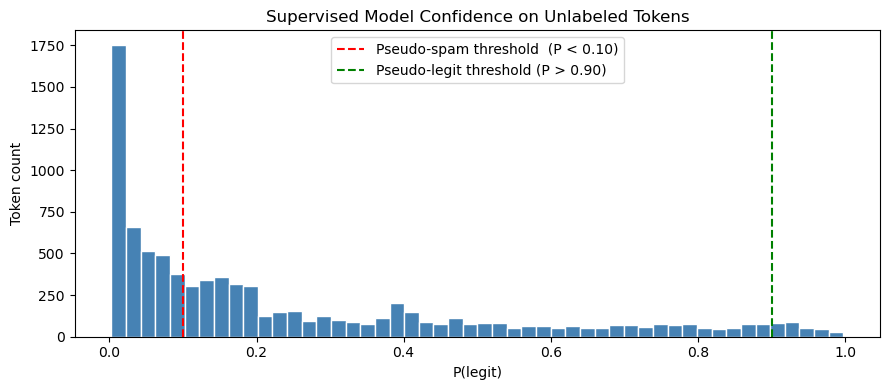

  threshold=0.10  pseudo-spam=3,760  pseudo-legit=293  total added=4,053
  threshold=0.15  pseudo-spam=4,505  pseudo-legit=479  total added=4,984
  threshold=0.20  pseudo-spam=5,320  pseudo-legit=596  total added=5,916


In [8]:
proba_unlabeled = best_model.predict_proba(X_unlabeled)[:, 1]   # P(legit)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(proba_unlabeled, bins=50, color='steelblue', edgecolor='white')
ax.axvline(0.1,  color='red',    linestyle='--', lw=1.5, label='Pseudo-spam threshold  (P < 0.10)')
ax.axvline(0.9,  color='green',  linestyle='--', lw=1.5, label='Pseudo-legit threshold (P > 0.90)')
ax.set_xlabel('P(legit)')
ax.set_ylabel('Token count')
ax.set_title('Supervised Model Confidence on Unlabeled Tokens')
ax.legend()
plt.tight_layout()
plt.show()

for t in [0.10, 0.15, 0.20]:
    ps = (proba_unlabeled < t).sum()
    pl = (proba_unlabeled > 1 - t).sum()
    print(f'  threshold={t:.2f}  pseudo-spam={ps:,}  pseudo-legit={pl:,}  total added={ps+pl:,}')

---
## Approach A — Confidence Thresholding (Pseudo-Labeling)

At each threshold, high-confidence predictions on unlabeled tokens are added to the training set as pseudo-labels. A fresh LightGBM is retrained on the expanded dataset and evaluated on the original test set.

In [9]:
# Retrieve the best hyperparameters from the saved model
best_params = best_model.get_params()
best_params.update({'random_state': RANDOM_STATE, 'n_jobs': -1, 'verbose': -1})
print('LightGBM params used for retraining:')
for k, v in best_params.items(): print(f'  {k}: {v}')

LightGBM params used for retraining:
  boosting_type: gbdt
  class_weight: balanced
  colsample_bytree: 0.8720213214995577
  importance_type: split
  learning_rate: 0.06017210546933224
  max_depth: 4
  min_child_samples: 27
  min_child_weight: 0.001
  min_split_gain: 0.0
  n_estimators: 226
  n_jobs: -1
  num_leaves: 28
  objective: None
  random_state: 42
  reg_alpha: 0.6884999007653664
  reg_lambda: 0.11638719101688721
  subsample: 0.9660854910505922
  subsample_for_bin: 200000
  subsample_freq: 0
  verbose: -1


In [10]:
for threshold in [0.10, 0.15, 0.20]:
    mask_spam  = proba_unlabeled < threshold
    mask_legit = proba_unlabeled > (1 - threshold)

    X_pseudo = X_unlabeled[mask_spam | mask_legit]
    y_pseudo = np.where(mask_spam[mask_spam | mask_legit], 0, 1)

    X_combined = np.vstack([X_train, X_pseudo])
    y_combined = np.concatenate([y_train, y_pseudo])

    model_pl = lgb.LGBMClassifier(**best_params)
    model_pl.fit(X_combined, y_combined)

    y_pred  = model_pl.predict(X_test)
    y_proba = model_pl.predict_proba(X_test)[:, 1]

    entry = {
        'Approach':   f'Pseudo-label (threshold={threshold})',
        'Train size': len(y_combined),
        'F1-macro':   f1_score(y_test, y_pred, average='macro'),
        'ROC-AUC':    roc_auc_score(y_test, y_proba),
        'F1-spam':    f1_score(y_test, y_pred, pos_label=0),
        'F1-legit':   f1_score(y_test, y_pred, pos_label=1),
    }
    results.append(entry)
    print(f"  t={threshold}  added={len(y_pseudo):,}  "
          f"F1-macro={entry['F1-macro']:.4f}  AUC={entry['ROC-AUC']:.4f}")

  t=0.1  added=4,053  F1-macro=0.8520  AUC=0.9499
  t=0.15  added=4,984  F1-macro=0.8648  AUC=0.9495
  t=0.2  added=5,916  F1-macro=0.8666  AUC=0.9493


---
## Approach B — Self-Training (sklearn)

`SelfTrainingClassifier` wraps LightGBM and iteratively adds confident predictions to the labeled set until no new samples meet the threshold or max iterations are reached.

In [11]:
# Combine labeled + unlabeled; use -1 as the marker for unlabeled
X_all = np.vstack([X_train, X_unlabeled])
y_all = np.concatenate([y_train, np.full(len(X_unlabeled), -1)])

print(f'Combined set: {len(y_all):,} tokens  (labeled={( y_all!=-1).sum():,}, unlabeled={( y_all==-1).sum():,})')

Combined set: 11,274 tokens  (labeled=2,524, unlabeled=8,750)


In [12]:
for st_threshold in [0.90, 0.80]:
    base_lgb = lgb.LGBMClassifier(**best_params)
    st_clf   = SelfTrainingClassifier(
        base_lgb,
        threshold=st_threshold,
        max_iter=10,
        verbose=False
    )
    st_clf.fit(X_all, y_all)

    y_pred  = st_clf.predict(X_test)
    y_proba = st_clf.predict_proba(X_test)[:, 1]

    n_iter    = st_clf.n_iter_
    n_labeled = (st_clf.transduction_ != -1).sum()

    entry = {
        'Approach':   f'Self-Training (threshold={st_threshold})',
        'Train size': int(n_labeled),
        'F1-macro':   f1_score(y_test, y_pred, average='macro'),
        'ROC-AUC':    roc_auc_score(y_test, y_proba),
        'F1-spam':    f1_score(y_test, y_pred, pos_label=0),
        'F1-legit':   f1_score(y_test, y_pred, pos_label=1),
    }
    results.append(entry)
    print(f"  threshold={st_threshold}  iters={n_iter}  labeled={n_labeled:,}  "
          f"F1-macro={entry['F1-macro']:.4f}  AUC={entry['ROC-AUC']:.4f}")

  threshold=0.9  iters=10  labeled=9,795  F1-macro=0.8557  AUC=0.9461
  threshold=0.8  iters=10  labeled=10,764  F1-macro=0.8611  AUC=0.9458


---
## 6. Results Comparison

In [13]:
results_df = pd.DataFrame(results)
print('=== Semi-Supervised vs Supervised Baseline ===')
print(results_df[['Approach','Train size','F1-macro','ROC-AUC','F1-spam','F1-legit']].to_string(index=False))

# Highlight improvement over baseline
baseline_f1 = results_df.iloc[0]['F1-macro']
results_df['Δ F1-macro'] = results_df['F1-macro'] - baseline_f1
print(f'\nBaseline F1-macro: {baseline_f1:.4f}')
print(results_df[['Approach','Δ F1-macro']].to_string(index=False))

=== Semi-Supervised vs Supervised Baseline ===
                        Approach  Train size  F1-macro  ROC-AUC  F1-spam  F1-legit
Supervised only (LightGBM tuned)        2524  0.883822 0.956160 0.897351  0.870293
    Pseudo-label (threshold=0.1)        6577  0.851980 0.949868 0.856631  0.847328
   Pseudo-label (threshold=0.15)        7508  0.864841 0.949529 0.870337  0.859345
    Pseudo-label (threshold=0.2)        8440  0.866581 0.949308 0.873239  0.859922
   Self-Training (threshold=0.9)        9795  0.855712 0.946055 0.859712  0.851711
   Self-Training (threshold=0.8)       10764  0.861138 0.945819 0.866785  0.855491

Baseline F1-macro: 0.8838
                        Approach  Δ F1-macro
Supervised only (LightGBM tuned)    0.000000
    Pseudo-label (threshold=0.1)   -0.031842
   Pseudo-label (threshold=0.15)   -0.018981
    Pseudo-label (threshold=0.2)   -0.017241
   Self-Training (threshold=0.9)   -0.028110
   Self-Training (threshold=0.8)   -0.022684


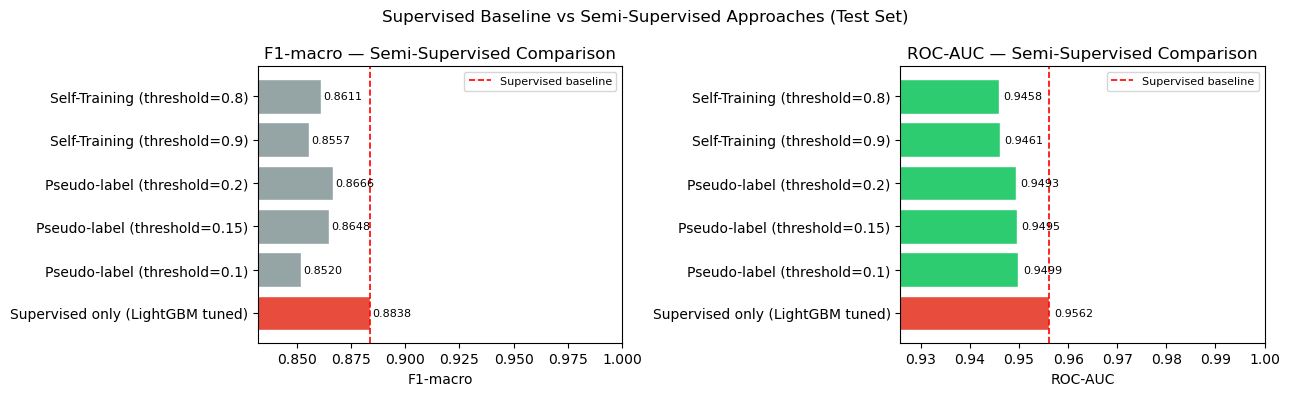

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, metric, title in zip(axes, ['F1-macro', 'ROC-AUC'], ['F1-macro', 'ROC-AUC']):
    colors = ['#e74c3c' if i == 0 else
              ('#2ecc71' if results_df.iloc[i][metric] > baseline_f1 else '#95a5a6')
              for i in range(len(results_df))]
    bars = ax.barh(results_df['Approach'], results_df[metric],
                   color=colors, edgecolor='white')
    ax.axvline(results_df.iloc[0][metric], color='red', linestyle='--',
               lw=1.2, label='Supervised baseline')
    ax.set_xlabel(metric)
    ax.set_title(f'{title} — Semi-Supervised Comparison')
    ax.set_xlim(results_df[metric].min() - 0.02, 1.0)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=8)
    ax.legend(fontsize=8)

plt.suptitle('Supervised Baseline vs Semi-Supervised Approaches (Test Set)', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Pseudo-Label Distribution Analysis

Examine what kind of tokens get pseudo-labeled — are they consistent with what we know about spam?

In [15]:
# Use the threshold=0.10 pseudo-labels for analysis
mask_spam_pl  = proba_unlabeled < 0.10
mask_legit_pl = proba_unlabeled > 0.90

pseudo_spam  = unlabeled[FEATURE_COLS][mask_spam_pl]
pseudo_legit = unlabeled[FEATURE_COLS][mask_legit_pl]

print(f'Pseudo-spam tokens:  {len(pseudo_spam):,}')
print(f'Pseudo-legit tokens: {len(pseudo_legit):,}')
print(f'Unassigned tokens:   {(~mask_spam_pl & ~mask_legit_pl).sum():,}  (below confidence threshold)')

key_features = ['n_unique_senders','sender_receiver_ratio','n_distinct_blocks',
                'top1_sender_share','value_std','zero_value_ratio']

compare = pd.DataFrame({
    'Pseudo-spam (P<0.10)':  pseudo_spam[key_features].median(),
    'Pseudo-legit (P>0.90)': pseudo_legit[key_features].median(),
}).T

print('\nMedian feature values of pseudo-labeled tokens:')
print(compare.round(4).to_string())

Pseudo-spam tokens:  3,760
Pseudo-legit tokens: 293
Unassigned tokens:   4,697  (below confidence threshold)

Median feature values of pseudo-labeled tokens:
                       n_unique_senders  sender_receiver_ratio  n_distinct_blocks  top1_sender_share     value_std  zero_value_ratio
Pseudo-spam (P<0.10)                2.0                    1.0                2.0              0.875  6.531363e+07               1.0
Pseudo-legit (P>0.90)              21.0                    0.9               34.0              0.250  3.618791e+04               0.0


---
## 8. Summary & Conclusions

### Results

| Approach | Train size | F1-macro | Δ vs baseline |
|---|---|---|---|
| Supervised only (LightGBM tuned) | 2,524 | **0.8838** | — |
| Pseudo-label (threshold=0.10) | 6,577 | 0.8520 | −0.032 |
| Pseudo-label (threshold=0.15) | 7,508 | 0.8648 | −0.019 |
| Pseudo-label (threshold=0.20) | 8,440 | 0.8666 | −0.017 |
| Self-Training (threshold=0.90) | 9,795 | 0.8557 | −0.028 |
| Self-Training (threshold=0.80) | 10,764 | 0.8611 | −0.023 |

### Did semi-supervised learning help?

**No — every approach degraded performance.** The supervised-only model (F1-macro = 0.8838, ROC-AUC = 0.9562) outperformed all semi-supervised variants. The drop ranges from −0.017 (pseudo-label at t=0.20) to −0.032 (pseudo-label at t=0.10). Adding more pseudo-labeled tokens slightly softens the drop but never recovers to baseline.

### Why did it fail?

**1. The labeled set is already representative.** With 3,606 tokens and strong behavioral features, the supervised model generalises well. There is little distributional information in the unlabeled tokens that the model has not already captured.

**2. Severe class skew in pseudo-labels.** At threshold 0.10, the model confidently labels 4,053 tokens as spam but only 293 as legit — a 14:1 ratio. Adding this many pseudo-spam samples pushes the training distribution further out of balance and likely biases the retrained model toward over-predicting spam, hurting legit recall.

**3. The unlabeled tokens are a different type of spam.** The pseudo-spam sanity check reveals a distinct pattern: median `zero_value_ratio = 1.0` (all transfers are zero-value) and `sender_receiver_ratio = 1.0` (1 sender, 1 receiver — barely any airdrop at all). These are likely dormant or minimally-deployed contracts, not the mass-airdrop spam the original model was trained on. Mixing in these tokens adds noise rather than signal.

**4. The 4,697 uncertain tokens (53%) cannot be resolved.** More than half the unlabeled set sits in the ambiguous confidence band — the model is genuinely unsure about them. These are likely the most interesting cases (novel spam patterns, honeypots, niche legit tokens) and are exactly the tokens that would benefit most from additional data sources or manual review.

### Recommendation

**Retain the supervised-only LightGBM model** for final deployment. Semi-supervised learning is not beneficial here given the high quality and representativeness of the existing labeled set. Future improvements should focus on expanding the ground-truth labels rather than pseudo-labeling — for example, by incorporating Etherscan community tags, DeFi protocol allow-lists, or extending the analysis window beyond 1,000 blocks.